### **Modelagem Numérica do Acoplamento Hidromecânico em Reservatórios**

Este notebook tem por objetivo facilitar a implementação e explicações referentes ao trabalho final da disciplina GA-020. O foco é desenvolver e implementar um modelo numérico computacional para simular a interação hidromecânica em reservatórios. O estudo visa quantificar a difusão transiente da pressão do fluido no meio poroso ao longo do tempo e, a partir desse campo de pressões, utilizar o acoplamento de Biot como força interna motriz para determinar a resposta elástica e a consequente deformação estrutural da rocha.

### **Modelo matemático e formulação Variacional do problema**

Considere o sistema acoplado (uma via) governado pelas seguintes equações diferenciais parciais:

$$
\begin{cases}
\beta\dfrac{\partial P}{\partial t} - \nabla\cdot\left(\dfrac{k}{\mu_f}\nabla P\right)=0, \\[10pt]
\nabla\cdot\sigma(\mathbf{u}) - \nabla P = \mathbf{0},
\end{cases}
$$

onde o tensor de tensões para elasticidade linear isotrópica é dado por

$$
\sigma(\mathbf{u}) = 2\mu\,\varepsilon(\mathbf{u}) + \lambda\,\operatorname{tr}(\varepsilon(\mathbf{u}))\,\mathbf{I},
$$

e o tensor de pequenas deformações é

$$
\varepsilon(\mathbf{u}) = \frac{1}{2} \left( \nabla\mathbf{u} + \nabla\mathbf{u}^{T} \right).
$$

## **O Problema Discreto**

Aplicando o método de Euler implícito para a discretização temporal da equação da difusão de pressão, a formulação variacional (forma fraca) consiste em:

**1. Problema Hidráulico:**
Encontrar a pressão atual $P^{n+1}\in V$ tal que, para toda função teste escalar $q\in V$,

$$
\beta \int_{\Omega} P^{n+1}q\,d\Omega + \Delta t \int_{\Omega} \frac{k}{\mu_f} \nabla P^{n+1}\cdot\nabla q\,d\Omega = \beta \int_{\Omega} P^n q\,d\Omega.
$$

**2. Problema Mecânico:**
Multiplicando a equação de equilíbrio por uma função teste vetorial $\mathbf{v}$ e integrando por partes apenas o termo da tensão (desprezando os termos naturais de contorno), a formulação variacional consiste em encontrar o deslocamento $\mathbf{u}\in W$ tal que, para toda função teste vetorial $\mathbf{v}\in W$,

$$
\int_{\Omega} \sigma(\mathbf{u}) : \varepsilon(\mathbf{v}) \,d\Omega = - \int_{\Omega} \nabla P_h \cdot \mathbf{v} \,d\Omega.
$$

### **Importação das dependências necessárias**


In [150]:
# fmt: off
# isort: off

import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
from firedrake import *

# isort: on
# fmt: on

### **Definição da geometria da malha e dos espaços de funções**

In [151]:
Lx = 200.0  # metros
Ly = 200.0  # metros
domain = RectangleMesh(100, 100, Lx, Ly)

V = VectorFunctionSpace(domain, "CG", 1)  # Deslocamento do Sólido (Vetor)
Q = FunctionSpace(domain, "CG", 1)  # Pressão do Fluido (Escalar)

# Funções teste
u = TrialFunction(V)
v = TestFunction(V)
P = TrialFunction(Q)
q = TestFunction(Q)

### **Definição dos parâmetros físicos do esqueleto poroso e do fluido**

**Relação entre $E$, $\nu$ e as Constantes de Lamé**

As constantes de Lamé podem ser escritas em função do módulo de Young $E$ e do coeficiente de Poisson $\nu$:

$$\mu = \frac{E}{2(1 + \nu)}, \quad \lambda = \frac{E\nu}{(1 + \nu)(1 - 2\nu)}$$

* **Módulo de Young ($E$):** Mede a rigidez axial do material (relação entre tensão e deformação linear na mesma direção).
  
  $$E = \frac{\sigma}{\epsilon_{\text{axial}}}$$

* **Coeficiente de Poisson ($\nu$):** Mede o acoplamento entre as deformações axial e lateral (o quanto o material "estufa" para os lados ao ser esmagado).
  
  $$\nu = -\frac{\epsilon_{\text{transversal}}}{\epsilon_{\text{axial}}}$$

In [152]:
# Sólido:
E = 10.0e9
nu = 0.25
mu_value = E / (2.0 * (1.0 + nu))
lambda_value = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = Constant(mu_value)
lambda_ = Constant(lambda_value)
I = Identity(domain.geometric_dimension)

# Dados do problema hidráulico
P_inj_val = 2.0e7  # 200 bar (Injeção na Esquerda)
P_prod_val = 1.0e7  # 100 bar (Produção na Direita)

# total_time = 5.0 * 24.0 * 3600   # 5 dias em segundos
total_time = 110.0 * 24.0 * 3600  # 5 dias em segundos

num_steps = 150
dt_value = total_time / num_steps

beta = Constant(1.0e-9)  # Compressibilidade (Pa^-1)
k_perm = Constant(1.0e-14)  # Permeabilidade da rocha (m²) k_perm = Constant(1.0e-15)
mu_f = Constant(1.0e-3)  # Viscosidade da Água (Pa.s)
dt = Constant(dt_value)  # Passo de tempo

### **Fundamentação Teórica da Elasticidade Linear Isotrópica**

O comportamento mecânico do esqueleto sólido em um meio poroso baseia-se na mecânica dos meios contínuos para pequenas deformações, onde o estado de deformação e o estado de tensão em qualquer ponto do domínio são descritos por tensores de segunda ordem.

#### 1. Cinemática: O Tensor de Pequenas Deformações ($\epsilon$)
A partir do vetor de deslocamento $\mathbf{u} = (u_x, u_y)^T$, que mapeia a mudança de posição de cada partícula do sólido no espaço bidimensional, define-se o gradiente de deslocamentos $\nabla \mathbf{u}$. Para o cenário de pequenas deformações (elasticidade linear), desprezam-se os termos não-lineares de ordem superior, resultando no **Tensor de Deformações Infinitesimais de Cauchy**:

$$\epsilon = \frac{1}{2} \left( \nabla \mathbf{u} + (\nabla \mathbf{u})^T \right) = \operatorname{sym}(\nabla \mathbf{u})$$

Em termos de componentes no plano $xy$, o tensor assume a forma simétrica:

$$\epsilon = \begin{bmatrix} \epsilon_{xx} & \epsilon_{xy} \\ \epsilon_{yx} & \epsilon_{yy} \end{bmatrix} = \begin{bmatrix} \frac{\partial u_x}{\partial x} & \frac{1}{2}\left(\frac{\partial u_x}{\partial y} + \frac{\partial u_y}{\partial x}\right) \\ \frac{1}{2}\left(\frac{\partial u_x}{\partial y} + \frac{\partial u_y}{\partial x}\right) & \frac{\partial u_y}{\partial y} \end{bmatrix}$$

A extração da parte simétrica do operador gradiente ($\operatorname{sym}$) é uma exigência cinemática fundamental. Ela garante que movimentos de rotação pura de corpo rígido (que não alteram as distâncias internas entre as partículas e, portanto, não geram forças internas) resultem em um tensor nulo ($\epsilon = 0$).

#### 2. Equação Constitutiva: Tensor de Tensões de Cauchy ($\sigma$) e as Constantes de Lamé
A resposta dinâmica do esqueleto sólido ao ser deformado é governada pela **Lei de Hooke Generalizada**. Para um meio puramente isotrópico (cujas propriedades mecânicas não variam com a direção espacial), a relação constitutiva mais elegante que vincula o tensor de tensões ($\sigma$) ao tensor de deformações ($\epsilon$) é expressa em termos das **Constantes de Lamé** ($\lambda$ e $\mu$):

$$\sigma = \lambda \operatorname{tr}(\epsilon) \mathbf{I} + 2\mu \epsilon$$

Onde:
* $\mathbf{I}$ é o tensor identidade de segunda ordem ($\mathbf{I} = \delta_{ij}$).
* $\operatorname{tr}(\epsilon)$ é o traço do tensor de deformações ($\epsilon_{xx} + \epsilon_{yy}$), operador invariante que quantifica matematicamente a **dilatação volumétrica local** ($\epsilon_v = \Delta V / V_0$).

Esta formulação decompõe fisicamente a resposta de tensão em dois mecanismos independentes:
1. **Comportamento Volumétrico ($\lambda \operatorname{tr}(\epsilon) \mathbf{I}$):** Modifica a magnitude das tensões normais hidrostáticas uniformemente quando ocorre variação no volume do elemento infinitesimal.
2. **Comportamento Desviatório ou Distorcional ($2\mu \epsilon$):** Atua diretamente nas deformações cisalhantes e diferenciais, quantificando a resistência do esqueleto sólido à mudança de forma sem alteração de volume.

In [153]:
# Tensores de deformação e tensão
def epsilon(w):
    return sym(grad(w))


def sigma(w):
    return lambda_ * tr(epsilon(w)) * I + 2.0 * mu * epsilon(w)

### Condições Iniciais, de Contorno e Partição da Fronteira

Para garantir que o sistema de equações diferenciais parciais acopladas de Biot seja um problema matematicamente bem-posto, é necessário definir o domínio físico ($\Omega$), o intervalo de tempo ($t \in (0, T]$) e um conjunto consistente de condições iniciais e de contorno. 

A fronteira total do domínio ($\partial\Omega$) é dividida em partições disjuntas para os campos mecânico e hidráulico:

#### 1. Fronteira Mecânica ($\partial\Omega = \Gamma_u \cup \Gamma_t$)
* **Deslocamento Prescrito ($\Gamma_u$):** Região onde o vetor de deslocamento é imposto ($\mathbf{u} = \bar{\mathbf{u}}$). No modelo atual, a fronteira esquerda está configurada com uma condição de Dirichlet homogênea:
  $$\mathbf{u} = (0.0, 0.0)^T \quad \text{em} \quad \Gamma_u \text{ (Esquerda)}$$
  Fisicamente, isto representa um suporte rígido engastado, impedindo qualquer movimento ou deformação do esqueleto sólido nessa extremidade.
* **Tração Prescrita ($\Gamma_t$):** Região onde forças de superfície ou tensões externas são aplicadas ($\sigma \mathbf{n} = \bar{\mathbf{t}}$). As restantes fronteiras que não possuem restrição explícita de deslocamento atuam como superfícies livres com tração nula ($\bar{\mathbf{t}} = \mathbf{0}$), permitindo que a rocha se deforme livremente em resposta à pressão interna do fluido.

#### 2. Fronteira Hidráulica ($\partial\Omega = \Gamma_p \cup \Gamma_v$)
* **Pressão Prescrita ($\Gamma_p$):** Região com carga hidráulica ou pressão de poro imposta ($p = \bar{p}$). O modelo simula um gradiente de pressão clássico de reservatório:
  * **Injeção (Esquerda):** Mantida com pressão elevada, simulando o contato com um poço injetor ou uma zona sobrepressurizada.
  * **Produção (Direita):** Mantida sob pressão referente às condições de extração, atuando como uma fronteira drenante (sumidouro) que permite a dissipação e troca de fluido com o exterior.
* **Fluxo Normal Prescrito ($\Gamma_v$):** Região onde a velocidade de filtragem de Darcy na direção normal é controlada ($\mathbf{v} \cdot \mathbf{n} = \bar{q}$). As fronteiras superior e inferior operam sob a condição de paredes impermeáveis:
  $$\mathbf{v} \cdot \mathbf{n} = 0 \quad \text{em} \quad \Gamma_v \text{ (Superior e Inferior)}$$
  Isto força o fluxo de fluido a deslocar-se estritamente de forma horizontal, da esquerda para a direita.

#### 3. Condições Iniciais ($t = 0$)
Como o acoplamento implementado é do tipo One-Way com uma mecânica quasi-estática (equilíbrio mecânico instantâneo a cada instante), a variável que dita a evolução temporal difusiva é a pressão de poro. Define-se o estado hidráulico inicial como um meio totalmente descarregado:
$$p(\mathbf{x}, 0) = 0.0 \quad \text{em todo o domínio } \Omega$$

#### Interdependência Física das Fronteiras
É fundamental destacar que as condições de contorno mecânicas e hidráulicas não são independentes do ponto de vista da resposta física do sistema. A restrição mecânica na esquerda impede a variação do volume local do esqueleto ($\nabla \cdot \mathbf{u} = 0$), o que altera o armazenamento poromecânico aparente e induz respostas de pressão de poro e tensões efetivas locais radicalmente distintas das regiões onde a malha possui total liberdade para expandir ou compactar.

In [154]:
# Condições iniciais e de contorno

# Condição Inicial -> Pressão nula em todo o domínio no tempo t=0
P0 = 1.0e7  # 150 bar
P_n = Function(Q, name="pressao_inicial").assign(P0)
P_initial = Function(Q, name="pressao_plot_inicial").assign(P_n)

# Condições de Contorno
bc_u = DirichletBC(V, Constant((0.0, 0.0)), 1)  # Engastado na esquerda
bc_P_esq = DirichletBC(Q, P_inj_val, 1)  # Pressão maior na esquerda
bc_P_dir = DirichletBC(Q, P_prod_val, 2)  # Pressão menor na direita
bcs_fluido = [bc_P_esq, bc_P_dir]

# Funções para armazenar os campos atuais - SOLUÇÕES
P_h = Function(Q, name="pressao_atual")
u_h = Function(V, name="deslocamento_atual")

In [155]:
# Forma fraca das edp's

a_fluido = (beta * P * q + dt * (k_perm / mu_f) * inner(grad(P), grad(q))) * dx
L_fluido = beta * P_n * q * dx

a_solido = inner(sigma(u), epsilon(v)) * dx
L_solido = -dot(grad(P_h), v) * dx

### Loop temporal

In [156]:
# Armazenar QOIs
times = np.linspace(0.0, total_time, num_steps + 1)  # discretização do domínio temporal
times_days = times / (24.0 * 3600.0)
mean_pressures = np.zeros(num_steps + 1)
max_displacements = np.zeros(num_steps + 1)
strain_energies = np.zeros(num_steps + 1)
domain_area = float(assemble(Constant(1.0) * dx(domain)))


# Estado inicial (t = 0)
mean_pressures[0] = float(assemble(P_n * dx) / domain_area)
u_mag_temp = Function(Q).interpolate(sqrt(dot(u_h, u_h)))
max_displacements[0] = u_mag_temp.dat.data_ro.max()
strain_energies[0] = float(assemble(0.5 * inner(sigma(u_h), epsilon(u_h)) * dx))


# Para plotagem dos campos em instantes arbitrários - Sugestão Volpatto
steps_to_plot = [
    int(num_steps * 0.05),
    int(num_steps * 0.25),
    int(num_steps * 0.60),
    num_steps,
]
P_instantes = []
u_instantes = []
t_instantes = []


for step in range(1, num_steps + 1):
    # Resolver problema hidráulico
    solve(
        a_fluido == L_fluido,
        P_h,
        bcs=bcs_fluido,
        solver_parameters={"ksp_type": "preonly", "pc_type": "lu"},
    )

    # Resolver problema mecânico
    solve(
        a_solido == L_solido,
        u_h,
        bcs=bc_u,
        solver_parameters={"ksp_type": "preonly", "pc_type": "lu"},
    )

    # Armazenar a Pressão Média (Pa)
    mean_pressures[step] = float(assemble(P_h * dx) / domain_area)

    # Deslocamento máximo
    u_mag_temp = Function(Q).interpolate(sqrt(dot(u_h, u_h)))
    max_displacements[step] = u_mag_temp.dat.data_ro.max()

    # Energia Elástica - AULA MEF (Volpatto)
    strain_energies[step] = float(assemble(0.5 * inner(sigma(u_h), epsilon(u_h)) * dx))

    # Salvar campos nos instantes definidos
    if step in steps_to_plot:
        P_instantes.append(Function(Q).assign(P_h))
        u_instantes.append(Function(V).assign(u_h))
        t_instantes.append(times_days[step])

    P_n.assign(P_h)

print("Simulação temporal concluída!\n")

Simulação temporal concluída!



### Quantidades de interesse do problema - Recuperadas a partir das soluções obtidas
| 1. Evolução Temporal | 2. Campos Espaciais (2D) | 3. Quantidades Derivadas |
| :--- | :--- | :--- |
| • Pressão média do reservatório <br> • Deslocamento máximo da rocha <br> • Energia elástica de deformação | • Campo de pressão Inicial <br> • Campo de pressão Final <br> • Magnitude e cinemática do deslocamento <br> • Campo de tensão de Von Mises | • Limites do deslocamento horizontal ($u_{x}$) <br> • Limites do deslocamento vertical ($u_{y}$) <br> • Pico da magnitude do deslocamento ($\|u\|$) <br> • Energia elástica total |

In [157]:
# Quantidades derivadas

print("Quantidades de interesse de engenharia\n")
print("-----------------------------------------")
u_x = Function(Q, name="u_x").interpolate(u_h[0])
u_y = Function(Q, name="u_y").interpolate(u_h[1])
u_mag = Function(Q, name="u_mag").interpolate(sqrt(dot(u_h, u_h)))
strain_energy = 0.5 * assemble(inner(sigma(u_h), epsilon(u_h)) * dx)

print(f"u_x em [{u_x.dat.data_ro.min():.6e}, {u_x.dat.data_ro.max():.6e}] m")
print(f"u_y em [{u_y.dat.data_ro.min():.6e}, {u_y.dat.data_ro.max():.6e}] m")
print(f"|u| máximo: {u_mag.dat.data_ro.max():.6e} m")
print(f"Energia elástica total: {float(strain_energy):.6e} J")
print("-----------------------------------------\n")

Quantidades de interesse de engenharia

-----------------------------------------
u_x em [0.000000e+00, 9.304655e-02] m
u_y em [-1.833687e-02, 1.830228e-02] m
|u| máximo: 9.304655e-02 m
Energia elástica total: 6.013034e+07 J
-----------------------------------------



### Evolução temporal

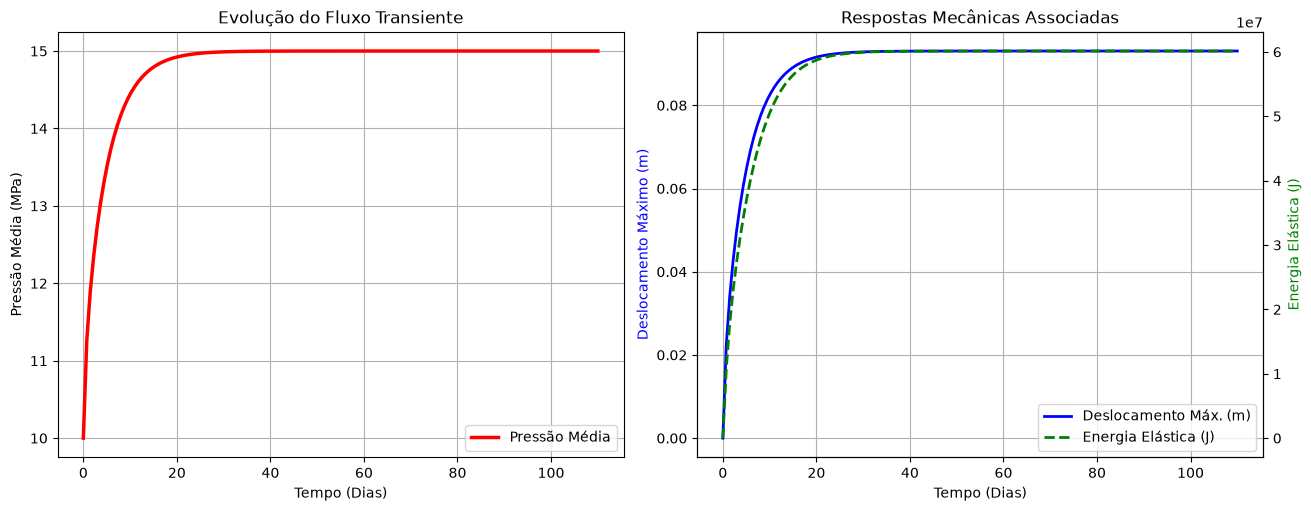

In [158]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax1.plot(times_days, mean_pressures / 1e6, "r-", linewidth=2.5, label="Pressão Média")
ax1.set_xlabel("Tempo (Dias)")
ax1.set_ylabel("Pressão Média (MPa)")
ax1.grid(True)
ax1.legend(loc="lower right")
ax1.set_title("Evolução do Fluxo Transiente")

ax2_disp = ax2
ax2_energy = ax2.twinx()

line1 = ax2_disp.plot(
    times_days, max_displacements, "b-", linewidth=2, label="Deslocamento Máx. (m)"
)
line2 = ax2_energy.plot(
    times_days, strain_energies, "g--", linewidth=2, label="Energia Elástica (J)"
)

ax2_disp.set_xlabel("Tempo (Dias)")
ax2_disp.set_ylabel("Deslocamento Máximo (m)", color="b")
ax2_energy.set_ylabel("Energia Elástica (J)", color="g")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2_disp.legend(lines, labels, loc="lower right")
ax2_disp.grid(True)
ax2_disp.set_title("Respostas Mecânicas Associadas")

# plt.savefig("historico_temporal.png", dpi=300)
plt.show()

### **Evolução espacial do campo de pressões e de deslocamentos**

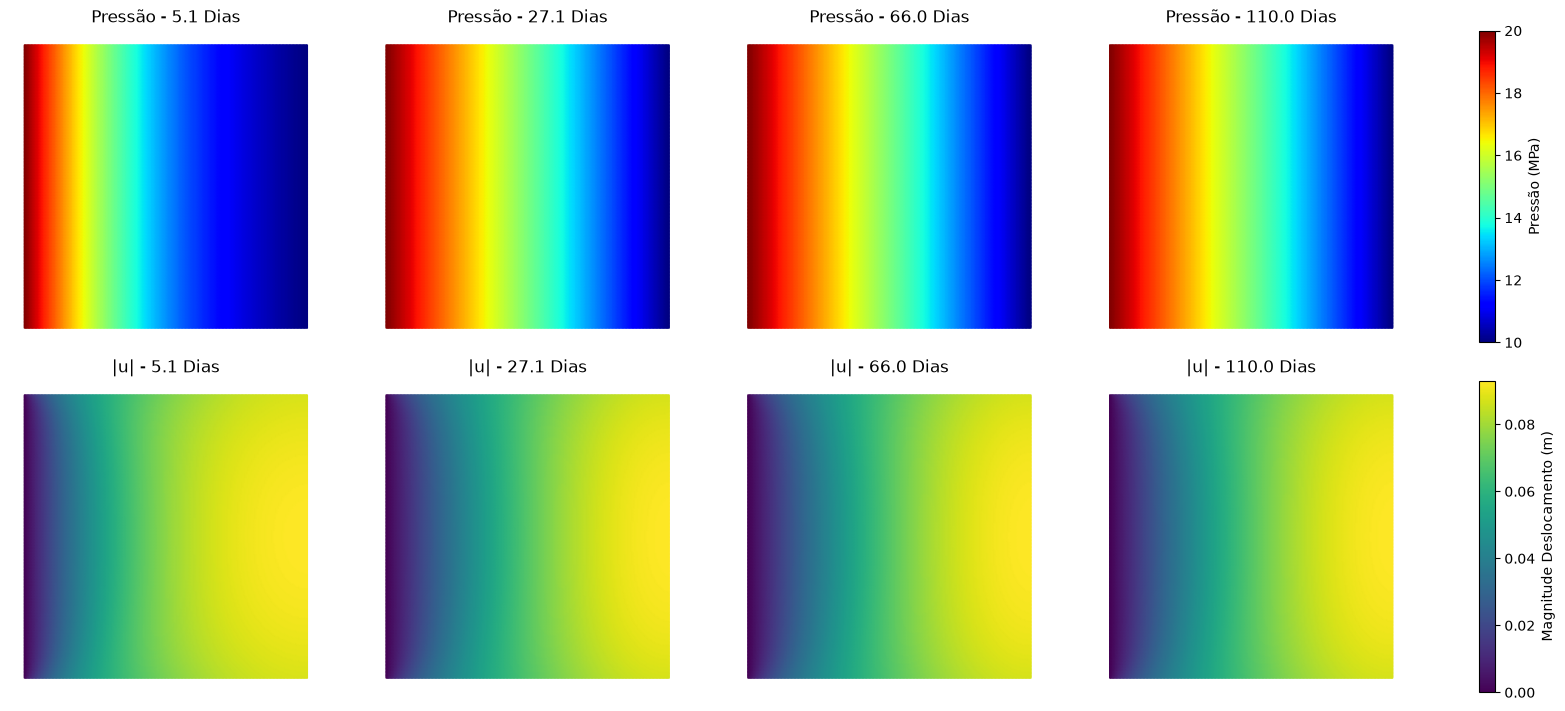

In [161]:
num_instantes = len(t_instantes)
fig_spatial, axes = plt.subplots(
    2, num_instantes, figsize=(16, 7), constrained_layout=True
)

for i in range(num_instantes):
    # Linha 1: Evolução da Pressão
    P_MPa = Function(Q).assign(P_instantes[i] / 1e6)
    c1 = tripcolor(P_MPa, axes=axes[0, i], cmap="jet", vmin=10.0, vmax=20.0)
    axes[0, i].set_title(f"Pressão - {t_instantes[i]:.1f} Dias")
    axes[0, i].set_aspect("equal")
    axes[0, i].axis("off")

    # Linha 2: Evolução do Deslocamento
    u_mag = Function(Q).interpolate(sqrt(dot(u_instantes[i], u_instantes[i])))
    c2 = tripcolor(u_mag, axes=axes[1, i], cmap="viridis")
    axes[1, i].set_title(f"|u| - {t_instantes[i]:.1f} Dias")
    axes[1, i].set_aspect("equal")
    axes[1, i].axis("off")

# Adicionar barras de cor para o painel
fig_spatial.colorbar(
    c1, ax=axes[0, :], label="Pressão (MPa)", location="right", aspect=20
)
fig_spatial.colorbar(
    c2, ax=axes[1, :], label="Magnitude Deslocamento (m)", location="right", aspect=20
)

plt.show()